In [ ]:
#1-Data importing and cleaning
import numpy as np
import pandas as pd

from urllib.request import urlopen
from zipfile import ZipFile
from io import BytesIO

df=pd.read_csv("global_power_plant_database.csv")
print(df.head(10))
print("Columns found:", df.columns)

#Cleaning
#1-Remove duplicates
df_cleaned = df.drop_duplicates()
print("Number of duplicates removed:", len(df) - len(df_cleaned))
#Identify missing values and handle them appropriately
missing_values_count = df_cleaned.isnull().sum()
print("Missing values count:\n", missing_values_count)
#Use NumPy to convert relevant columns to numerical types if necessary.
df_cleaned['capacity_mw'] = pd.to_numeric(df_cleaned['capacity_mw'], errors='coerce')
print("Data types after conversion:\n", df_cleaned.dtypes)



  country country_long                                               name  \
0     AFG  Afghanistan       Kajaki Hydroelectric Power Plant Afghanistan   
1     AFG  Afghanistan                                       Kandahar DOG   
2     AFG  Afghanistan                                       Kandahar JOL   
3     AFG  Afghanistan      Mahipar Hydroelectric Power Plant Afghanistan   
4     AFG  Afghanistan   Naghlu Dam Hydroelectric Power Plant Afghanistan   
5     AFG  Afghanistan  Nangarhar (Darunta) Hydroelectric Power Plant ...   
6     AFG  Afghanistan            Northwest Kabul Power Plant Afghanistan   
7     AFG  Afghanistan  Pul-e-Khumri Hydroelectric Power Plant Afghani...   
8     AFG  Afghanistan   Sarobi Dam Hydroelectric Power Plant Afghanistan   
9     ALB      Albania                                         Bistrica 1   

      gppd_idnr  capacity_mw  latitude  longitude primary_fuel other_fuel1  \
0  GEODB0040538        33.00   32.3220    65.1190        Hydro         NaN

C:\Users\Debohi\AppData\Local\Temp\ipykernel_33876\3350876963.py:9: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("global_power_plant_database.csv")


In [18]:
#Exploration
import pandas as pd

#Utilize Pandas to summarize key statistics (mean, median, standard deviation) for numerical columns

mean_capacity = df_cleaned['capacity_mw'].mean()
median_capacity = df_cleaned['capacity_mw'].median()
std_capacity = df_cleaned['capacity_mw'].std()
print("Mean capacity (MW):", mean_capacity)
print("Median capacity (MW):", median_capacity)
print("Standard deviation of capacity (MW):", std_capacity)
#Explore the distribution of power plants by country and fuel type
country_distribution = df_cleaned['country_long'].value_counts()
fuel_type_distribution = df_cleaned['primary_fuel'].value_counts()
print("Distribution of power plants by country:\n", country_distribution)
print("Distribution of power plants by fuel type:\n", fuel_type_distribution)


Mean capacity (MW): 163.35514790637166
Median capacity (MW): 16.744999999999997
Standard deviation of capacity (MW): 489.6360717012982
Distribution of power plants by country:
 country_long
United States of America    9833
China                       4235
United Kingdom              2751
Brazil                      2360
France                      2155
                            ... 
Lesotho                        1
Western Sahara                 1
Suriname                       1
Palestine                      1
Guinea-Bissau                  1
Name: count, Length: 167, dtype: int64
Distribution of power plants by fuel type:
 primary_fuel
Solar             10665
Hydro              7156
Wind               5344
Gas                3998
Coal               2330
Oil                2320
Biomass            1430
Waste              1068
Nuclear             195
Geothermal          189
Storage             135
Other                43
Cogeneration         41
Petcoke              12
Wave and Tidal 

In [20]:
#Statistical Analysis

#Perform a statistical analysis of power output by fuel type using NumPy’s statistical functions
fuel_type_stats = df_cleaned.groupby('primary_fuel')['capacity_mw'].agg(['mean', 'median', 'std'])
print("Statistical analysis of power output by fuel type:\n", fuel_type_stats)

#Use hypothesis testing to determine if the mean power output differs significantly between different fuel types
from scipy import stats
fuel_types = df_cleaned['primary_fuel'].unique()
for i in range(len(fuel_types)):
    for j in range(i + 1, len(fuel_types)):
        fuel_type1 = fuel_types[i]
        fuel_type2 = fuel_types[j]
        group1 = df_cleaned[df_cleaned['primary_fuel'] == fuel_type1]['capacity_mw'].dropna()
        group2 = df_cleaned[df_cleaned['primary_fuel'] == fuel_type2]['capacity_mw'].dropna()
        t_stat, p_value = stats.ttest_ind(group1, group2)
        print(f"Hypothesis test between {fuel_type1} and {fuel_type2}: t-statistic={t_stat}, p-value={p_value}")
        

Statistical analysis of power output by fuel type:
                        mean      median          std
primary_fuel                                        
Biomass           23.972938     9.45000    39.461805
Coal             843.579828   600.00000   888.187187
Cogeneration      98.731707    31.90000   283.428252
Gas              373.449375   147.50000   560.934146
Geothermal        67.130952    30.00000   114.640890
Hydro            147.171551    20.00000   549.809328
Nuclear         2091.855179  1888.00000  1303.509273
Oil              112.878754     9.00000   392.009039
Other             84.020000    40.00000   145.891392
Petcoke          202.048125    65.48875   476.986459
Solar             17.657039     5.80000    41.939412
Storage           12.683704     4.90000    35.574631
Waste             13.809657     4.80000    20.582503
Wave and Tidal    55.220000     5.00000   101.440708
Wind              49.224126    27.00000   106.138355
Hypothesis test between Hydro and Solar: t-stat

In [22]:
#Time Series Analysis
#If the dataset includes time-related data (e.g., commissioning year), analyze trends in power plant capacity over time
df_cleaned['commissioning_year'] = pd.to_numeric(df_cleaned['commissioning_year'], errors='coerce')
capacity_trends = df_cleaned.groupby('commissioning_year')['capacity_mw'].sum()
print("Trends in power plant capacity over time:\n", capacity_trends)

#Explore how the mix of fuel types for power generation has evolved over the years

fuel_type_trends = df_cleaned.groupby(['commissioning_year', 'primary_fuel']).size().unstack(fill_value=0)
print("Trends in fuel types for power generation over the years:\n", fuel_type_trends)


Trends in power plant capacity over time:
 commissioning_year
1896.000000        2.00
1899.000000        3.20
1900.000000       88.94
1901.000000        7.40
1902.000000       23.50
                 ...   
2019.000000    22848.00
2019.000000       22.40
2019.411765      340.00
2019.796326      500.80
2020.000000     5696.00
Name: capacity_mw, Length: 2023, dtype: float64
Trends in fuel types for power generation over the years:
 primary_fuel        Hydro  Gas  Oil  Biomass  Coal  Other  Waste  \
commissioning_year                                                 
1896.000000             1    0    0        0     0      0      0   
1899.000000             1    0    0        0     0      0      0   
1900.000000             3    1    2        0     0      0      0   
1901.000000             2    0    0        0     0      0      0   
1902.000000             4    0    0        0     0      0      0   
...                   ...  ...  ...      ...   ...    ...    ...   
2019.000000            

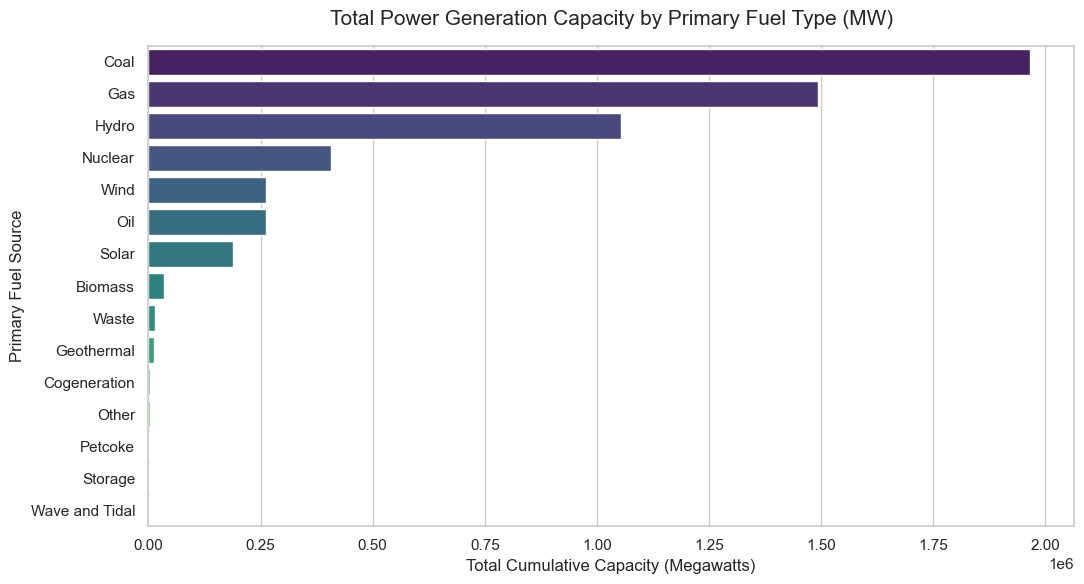

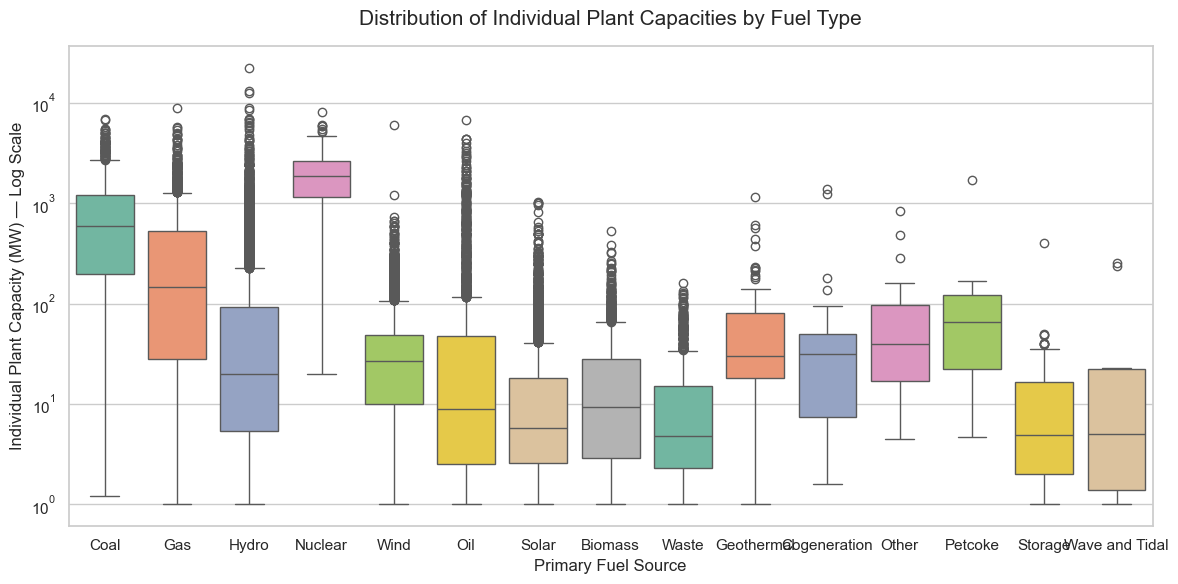

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
df_cleaned = df.drop_duplicates()
df_gps = df_cleaned.dropna(subset=['latitude', 'longitude', 'primary_fuel', 'capacity_mw'])
sns.set_theme(style="whitegrid")

# Graphique 1 : Distribution géographique
fig1, ax1 = plt.subplots(figsize=(14, 8))
sns.scatterplot(
    data=df_gps,
    x='longitude',
    y='latitude',
    hue='primary_fuel',
    size='capacity_mw',
    sizes=(10, 500),
    alpha=0.5,
    palette='tab10',
    ax=ax1
)
ax1.set_title('Geographical Distribution of Power Plants by Fuel Type & Capacity', fontsize=15, pad=15)
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Fuel Type & Capacity (MW)')
plt.tight_layout()
plt.savefig('power_plant_geographical_distribution.png', dpi=300)
plt.close(fig1)

# Graphique 2 : Capacité totale par type de carburant
fuel_capacity = (
    df_gps.groupby('primary_fuel')['capacity_mw']
    .sum()
    .reset_index()
    .sort_values(by='capacity_mw', ascending=False)
)

fig2, ax2 = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=fuel_capacity,
    x='capacity_mw',
    y='primary_fuel',
    palette='viridis',
    ax=ax2
)
ax2.set_title('Total Power Generation Capacity by Primary Fuel Type (MW)', fontsize=15, pad=15)
ax2.set_xlabel('Total Cumulative Capacity (Megawatts)', fontsize=12)
ax2.set_ylabel('Primary Fuel Source', fontsize=12)
plt.tight_layout()
plt.savefig('total_capacity_by_fuel.png', dpi=300)


# Graphique 3 : Boîte à moustaches des capacités (Échelle logarithmique)
fig3, ax3 = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_gps,
    x='primary_fuel',
    y='capacity_mw',
    palette='Set2',
    ax=ax3,
    order=fuel_capacity['primary_fuel'].tolist()
)
ax3.set_yscale('log')
ax3.set_title('Distribution of Individual Plant Capacities by Fuel Type', fontsize=15, pad=15)
ax3.set_xlabel('Primary Fuel Source', fontsize=12)
ax3.set_ylabel('Individual Plant Capacity (MW) — Log Scale', fontsize=12)
plt.tight_layout()
plt.savefig('capacity_distribution_boxplot.png', dpi=300)

plt.show()

Pour analyser les relations entre la géographie, la puissance et le type de carburant des centrales, les données textuelles et numériques sont d'abord standardisées et converties en une matrice numérique $X$ via un encodage one-hot. En calculant la matrice de covariance $\Sigma = \frac{1}{n} Z^T Z$, on quantifie la manière dont ces attributs varient ensemble. L'extraction des vecteurs propres et des valeurs propres de cette matrice permet ensuite de synthétiser la structure cachée du réseau énergétique : chaque vecteur propre définit un profil type ou un axe de variation (par exemple, l'opposition naturelle entre les parcs solaires locaux à faible capacité et les centrales thermiques massives), tandis que sa valeur propre associée mesure la quantité d'information globale capturée par cet axe. Cette décomposition matricielle, fondement de l'Analyse en Composantes Principales (ACP), permet ainsi de réduire la complexité des données tout en isolant mathématiquement les facteurs géographiques et techniques qui structurent la production d'énergie mondiale.

In [30]:
#Demonstrate matrix operations by analyzing relationships between different attributes (e.g., fuel type, capacity, and geographic location)

matrix = df_gps.pivot_table(index='primary_fuel', columns='country_long', values='capacity_mw', aggfunc='sum', fill_value=0)
print("Matrix of total capacity by fuel type and country:\n", matrix)


Matrix of total capacity by fuel type and country:
 country_long    Afghanistan  Albania  Algeria  Angola  Antarctica  Argentina  \
primary_fuel                                                                   
Biomass                0.00      0.0      0.0    0.00         0.0      0.000   
Coal                   0.00      0.0      0.0    0.00         0.0   4857.400   
Cogeneration           0.00      0.0      0.0    0.00         0.0      0.000   
Gas                   42.00      0.0  15179.0  163.68         0.0  13041.840   
Geothermal             0.00      0.0      0.0    0.00         0.0      0.000   
Hydro                238.55   1431.0     24.0  770.60         0.0   9999.710   
Nuclear                0.00      0.0      0.0    0.00         0.0   1763.000   
Oil                    0.00      0.0      0.0  136.90         6.6   1199.289   
Other                  0.00     98.0      0.0    0.00         0.0   1324.460   
Petcoke                0.00      0.0      0.0    0.00         0.0   

#7 (Integrating NumPy with Pandas and Matplotlib)

Optimizing Pandas via NumPy (Vectorized Operations)
To bypass slow Python loops (.apply()), NumPy runs element-wise operations directly at the C-engine level on Pandas structures.

Multi-Condition Rules (np.select): Replaces nested if/else statements or complex lambda chains with an optimized vector rule engine.

Fast Data Segmentation (np.digitize): Instantly segments continuous variables (e.g., plant capacity in MW) into discrete ordered bins.





In [31]:


# 1. Multi-condition rule engine using np.select
conditions = [
    (df['capacity_mw'] >= 1000) & (df['primary_fuel'].isin(['Coal', 'Gas'])),
    (df['primary_fuel'].isin(['Solar', 'Wind']))
]
choices = ['High-Emission Giant', 'Renewable Energy']
df['plant_profile'] = np.select(conditions, choices, default='Standard Thermal')

# 2. Fast binning using np.digitize
thresholds = np.array([0, 100, 500, 1500, 5000])
df['capacity_tier'] = np.digitize(df['capacity_mw'], thresholds)

Enhancing Matplotlib via NumPy (Mathematical Modeling)
Matplotlib reads coordinates from data arrays. Injecting NumPy's mathematical functions enables the creation of highly sophisticated analytical plots.

Polynomial Trendlines (np.polyfit & np.linspace): Extracts statistical regression coefficients and generates a perfectly smooth coordinate space to overlay a trendline onto a scatter plot.

Coordinate Grids for Spatial Plots (np.meshgrid): Transforms isolated 1D coordinate vectors into a 2D coordinate matrix, which is required to plot contour maps, spatial densities, or 3D surfaces.

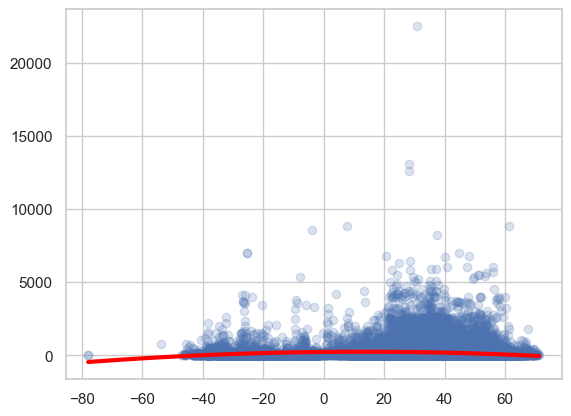

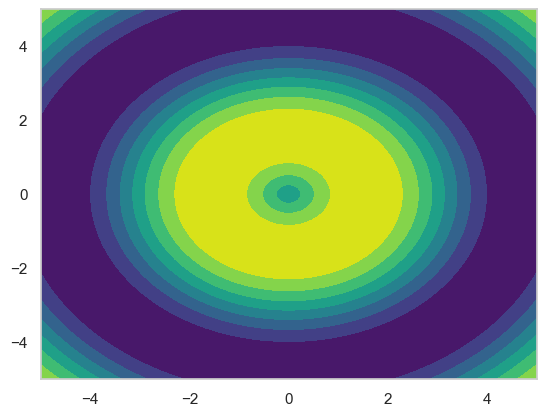

In [32]:


# 1. Mathematical Trendline (Degree 2 Polynomial Regression)
coeffs = np.polyfit(df['latitude'], df['capacity_mw'], 2)
smooth_x = np.linspace(df['latitude'].min(), df['latitude'].max(), 200)
fitted_y = np.polyval(coeffs, smooth_x)

plt.scatter(df['latitude'], df['capacity_mw'], alpha=0.2)
plt.plot(smooth_x, fitted_y, color='red', linewidth=3) # Overlay trendline
plt.show()

# 2. Coordinate Grid for Contour/Density Plots
X, Y = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
Z = np.sin(np.sqrt(X**2 + Y**2)) # Apply mathematical formula to the grid
plt.contourf(X, Y, Z, cmap='viridis')
plt.show()